# Parameters

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Import the central truth namespaces from constants.py
from constants import USB, FAN, DESIGN, TOTAL_MAX_LOAD_WATTS

# --- Input Power Points (USB-C PD) ---
# Use ranges and tolerances defined in USBCSpecs
v_in = np.linspace(USB.V_MIN * (1 - USB.V_TOLERANCE), 
                   USB.V_MAX * (1 + USB.V_TOLERANCE), 100)

# --- Output Parameters ---
v_out = FAN.V_NOMINAL
# Use the pre-calculated total load (Fans + System Logic) from constants.py
max_load_watts = TOTAL_MAX_LOAD_WATTS

print(f"Max System Load (Fans + Logic): {max_load_watts:.2f}W")

Max System Load (Fans + Logic): 42.73W


Design goals: maximize efficiency when using low power USB battery bank. Fit neatly inside pc fan air purifier case with minimal space concerns.

Design Specific Parameters

In [20]:
vce_sat_typ = 0.1
vce_sat_max = 0.2
vce_sat_min = 0
vbe_sat = 0.7
vout_thresh_release_latch = 2.0
vin_thresh_set_latch = 4.38-0.645+0.1 # should make just higher than falling threshold for en/uvlo so that it doesnt go into off state but not be latched
ratio_r3r4 = (vout_thresh_release_latch - vbe_sat) / (vbe_sat - vce_sat_typ)
power_budget_r1r2 = 0.01

V_USB_MIN = 4.5 # must turn on/at this voltage or lower since usb might not give more than 4.5V
V_USB_MAX = 22.5 # must still stay latched even if vin rises this high if vout not fallen yet
V_ON_FLOOR = 3.8 # must not turn on unless vin higher than this. rough based on 2.6v mosfet plateau voltage
V_OFF_FLOOR = 2 # turn off managed by external latch circuit if vout is high, but if vout is low, we should turn off if vin drops. this must also be lower than the latch circuit threshold since if vout is high, we want it to latch before ic would turn off by itself without latching
V_OFF_LATCH_FLOOR = 3 # when vout is on, off floor is 3v, this shuold be higher than ic's off floor so that we always latch, not just turn off by ic
MIN_HYS_GAP = 0.2 # min hystersis to prevent chatter during turn on while vout is low, ie voff max. from on to off non-latching.
LATCH_TO_IC_OFF_GAP = 0.2 #ensure latch always latches before ic would have turned off by normally looking at en/uvlo 
LATCH_TO_IC_ON_GAP = 0.1 # make sure that latch wont be latching if ic turns on and starts increasing the output. ie, 3.8v vin ic on, vout rises. we want to make sure latch wont think vin is too low and latch en/uvlo as soon as vout is on..
LATCH_VOUT_THRESH_CEIL = 2 # make sure vout is fully off before letting ic turn back on. 2V arbitrary. higher is risky since energy on output still might cause too much backfeed. lower the better
LATCH_VOUT_THRESH_FLOOR = 0 # not sur if needed
MAX_POWER_UW = 1000 # arbitrary power limit. lower the better. dcdc approximately has 0.1W to 1W loss
DELTA_T = 35 # temp change for tolerance calculations

V_LATCH_ON_FLOOR = V_OFF_FLOOR + LATCH_TO_IC_OFF_GAP
V_LATCH_ON_CEIL = V_ON_FLOOR - LATCH_TO_IC_ON_GAP

#from pcb v1
r1 = 100e3
r2 = 300e3

#latched but vin back high
ic_q1_sink = V_USB_MAX / r2 # worst case vce_q1 = 0
force_beta_q1 = 10
ib_q1 = ic_q1_sink / force_beta_q1
vbe_sat_q2 = vbe_sat
r3_options = np.linspace(1, 1e6, 10000)
r4_options = np.linspace(1, 1e6, 10000)
ib_q2 = (((V_LATCH_ON_FLOOR + V_LATCH_ON_CEIL) / 2) - vbe_sat_q2) / r4_options - vbe_sat_q2 / r3_options
vbe_sat_q3 = vbe_sat
#assume q2 fully saturated by high vin and base current, so vce 0v.
r5_options = np.linspace(1, 1e6, 10000)
r6_options = np.linspace(1, 1e6, 10000)
vce_sat_q2 = vce_sat_min
i_r5 = (vbe_sat_q3 -vce_sat_q2)/ r5_options
i_r6 = (LATCH_VOUT_THRESH_CEIL - vbe_sat_q3) / r6_options
vce_sat_q4 = vce_sat_max
i_r8 = (LATCH_VOUT_THRESH_CEIL - vce_sat_q4 - vbe_sat_q3) / r6_options
ic_q4 = i_r8
vbe_sat_q4 = vbe_sat
vce_sat_q3 = vce_sat_typ
r7_options = np.linspace(1, 1e6, 10000)
r8_options = np.linspace(1, 1e6, 10000)
i_r7 = (LATCH_VOUT_THRESH_CEIL - vbe_sat_q4 - vce_sat_q3 ) / r7_options
ib_q4 = i_r7 
ic_q3 = i_r7 
vce_sat_q4 = vce_sat_typ
i_r8 = (LATCH_VOUT_THRESH_CEIL - vce_sat_q4 - vbe_sat_q3 ) / r8_options
ib_q3 = i_r6 + i_r8 - ib_q1 - i_r5
beta_q3 = ic_q3 / ib_q3 
beta_q4 = ic_q4 / ib_q4

# when above latch_vout_thresh_ceil, beta_q3, beta_q1, shuold be 10, forced on. but if fall below latch_vout_thresh_ceil, then there shuold be insufficient current and beta should be higher than 10 and thus starts turning off. shuold be fully off before 0v obviously.
# when vout is at or below latch_vout_thresh_ceil, vin being between V_LATCH_ON_FLOOR and V_LATCH_OFF_FLOOR, latch should release, ie q2 saturated and q3 and q1 not satured ie vb q1 and vb q3 lower than vbe_sat ie ib q1 and ibq3 much lower than required fro beta of 10 or ideally 0 current.
#power = i_r5 * vin * vout*(ir6+ir8+ir7)
# how to change so we calculate the acceptable vlaues of r3 through r7?






In [45]:
import numpy as np

# --- Parameters & Constraints  ---
V_USB_MAX = 22.5
V_BE_SAT = 0.7
V_CE_SAT_TYP = 0.1
V_CE_SAT_MAX = 0.2
B_FORCED = 10
PWR_LIMIT = 50e-3 # 1000uW budget

# Thresholds 
V_IN_RESET_HIGH = V_LATCH_ON_CEIL # vin_thresh_set_latch
V_OUT_RELEASE = 4.0 
V_OUT_NOMINAL = 12.0

# Fixed from Netlist [cite: 3, 4]
R1 = 100e3
R2 = 300e3

def run_resistor_search():
    # E12 / E24 suggested values
    r_range = [1e3, 2.2e3, 4.7e3, 10e3, 22e3, 33e3, 47e3, 68e3, 100e3, 220e3]#, 470e3]
    valid_configs = []

    for r4 in r_range:
        for r3 in r_range:
            for r5 in r_range:
                for r6 in r_range:
                    for r7 in r_range:
                        for r8 in r_range:
                            # 2. Power Consumption Check
                            p_total = (V_USB_MAX**2 / (R1+R2)) + (V_OUT_NOMINAL**2 / r7) + (V_OUT_NOMINAL**2 / r8) + ((V_USB_MAX - V_BE_SAT) **2 / r4)
                            if p_total > PWR_LIMIT: continue

                            # 3. LATCHED STABILITY (VIN High, VOUT High) 
                            # Q2 is ON, but latch must hold.
                            # i_feedback must overcome i_r5_shunt + required base currents
                            i_r5_shunt = (V_BE_SAT - V_CE_SAT_TYP) / r5
                            ic_q1 = V_USB_MAX / R2
                            ic_q3 = V_OUT_NOMINAL / r7
                            ib_req = (ic_q1 / B_FORCED) + (ic_q3 / B_FORCED)
                            
                            # Feedback through Q4 (PNP)
                            i_feedback = (V_OUT_RELEASE - V_BE_SAT - V_CE_SAT_TYP)/r8 + (V_OUT_RELEASE - V_BE_SAT)/r6
                            
                            if i_feedback <= (i_r5_shunt + ib_req): continue

                            # 4. CORRECTED RESET CHECK (VIN High, VOUT Low) 
                            # When VOUT = 2V, the current sourced by R6 and R8  #descriptino wrong
                            # must be small enough that Q2 (through R5) pulls VB_Q3 below 0.5V.
                            i_source_reset = (V_OUT_RELEASE - 0.5)/r6
                            i_sink_reset = (0.5 - V_CE_SAT_MAX)/r5
                            
                            if i_sink_reset < i_source_reset:
                                continue # Q2 can't pull the node low enough to break latch
                            
                            # 1. Q2 Startup: Must saturate when VIN is high 
                            ib_q2_start = (V_IN_RESET_HIGH - V_BE_SAT)/r4 - (V_BE_SAT/r3)
                            if ib_q2_start < ( (V_USB_MAX/r6+V_USB_MAX/r8) / B_FORCED): 
                                continue 

                            valid_configs.append({"R3":r3,"R4":r4,"R5":r5,"R6":r6,"R7":r7,"R8":r8})
                            if len(valid_configs) >= 50: return valid_configs
    return valid_configs

results = run_resistor_search()
for cfg in results:
    print(cfg)

{'R3': 10000.0, 'R4': 22000.0, 'R5': 10000.0, 'R6': 220000.0, 'R7': 100000.0, 'R8': 47000.0}
{'R3': 10000.0, 'R4': 22000.0, 'R5': 10000.0, 'R6': 220000.0, 'R7': 220000.0, 'R8': 47000.0}
{'R3': 22000.0, 'R4': 22000.0, 'R5': 4700.0, 'R6': 68000.0, 'R7': 220000.0, 'R8': 33000.0}
{'R3': 22000.0, 'R4': 22000.0, 'R5': 10000.0, 'R6': 220000.0, 'R7': 33000.0, 'R8': 33000.0}
{'R3': 22000.0, 'R4': 22000.0, 'R5': 10000.0, 'R6': 220000.0, 'R7': 47000.0, 'R8': 33000.0}
{'R3': 22000.0, 'R4': 22000.0, 'R5': 10000.0, 'R6': 220000.0, 'R7': 68000.0, 'R8': 33000.0}
{'R3': 22000.0, 'R4': 22000.0, 'R5': 10000.0, 'R6': 220000.0, 'R7': 100000.0, 'R8': 33000.0}
{'R3': 22000.0, 'R4': 22000.0, 'R5': 10000.0, 'R6': 220000.0, 'R7': 100000.0, 'R8': 47000.0}
{'R3': 22000.0, 'R4': 22000.0, 'R5': 10000.0, 'R6': 220000.0, 'R7': 220000.0, 'R8': 33000.0}
{'R3': 22000.0, 'R4': 22000.0, 'R5': 10000.0, 'R6': 220000.0, 'R7': 220000.0, 'R8': 47000.0}
{'R3': 33000.0, 'R4': 22000.0, 'R5': 4700.0, 'R6': 68000.0, 'R7': 220000.0,

Appropriate Inductance Values

In [9]:
# Constants
ripple_ratio = 0.3 # Table1[Goal Delta I_L]
i_out_lim = 3.5

l_values = []

for v_in in input_voltage_operating_points:
    # Determine mode
    is_buck = v_in > v_out
    
    # Target Delta I_L (usually a percentage of load current)
    delta_i = ripple_ratio * i_out_lim
    
    if is_buck:
        l_calc = ((v_in - v_out) * v_out) / (delta_i * f_sw * v_in)
    else:
        # Boost formula
        l_calc = (v_in**2 * (v_out - v_in)) / (delta_i * f_sw * v_out**2)
    
    l_values.append(abs(l_calc)) # abs() handles the sign if Vin=Vout

# Final Inductor Choice (Worst Case)
required_l = max(l_values)

print(f"Calculated Inductances: {[f'{x*1e6:.2f} uH' for x in l_values]}")

NameError: name 'input_voltage_operating_points' is not defined

In [12]:
import numpy as np
import constants as cfg

# --- Configuration ---
# Operating points from your USB-C range
v_in_points = np.array([4.5, 9, 11.5, 15, 22.5])
target_v_out = cfg.FAN.V_NOMINAL
ripple_ratio = 0.3  # Target 30% inductor current ripple

# Use the derived max load from our constants
i_out_max = cfg.TOTAL_MAX_LOAD_WATTS / target_v_out

l_required_values = []

print(f"--- Inductor Requirement Analysis ---")
print(f"Target V_out: {target_v_out}V | Max Load: {i_out_max:.2f}A\n")

for v_in in v_in_points:
    # 1. Calculate Target Ripple (Delta I_L)
    delta_i_target = ripple_ratio * i_out_max
    
    # 2. Calculate required L for this specific V_in
    if v_in > target_v_out:
        # Buck Mode
        l_calc = (target_v_out * (v_in - target_v_out)) / (delta_i_target * cfg.DESIGN.F_SW_HZ * v_in)
    else:
        # Boost Mode
        # Note: In boost, ripple is highest at low V_in
        duty_cycle = 1 - (v_in / target_v_out)
        l_calc = (v_in * duty_cycle) / (delta_i_target * cfg.DESIGN.F_SW_HZ)
    
    l_required_values.append(abs(l_calc))
    
    mode = "BUCK " if v_in > target_v_out else "BOOST"
    print(f"V_in: {v_in:>4}V | Mode: {mode} | Req. L: {l_calc*1e6:>6.2f} µH")

# --- Validation against Selected Component ---
max_req_l = max(l_required_values)
actual_l = cfg.SYSTEM_L_HENRY

# Peak Current Check (I_peak = I_out_avg + Delta_I/2)
# Using worst-case ripple for the selected 47uH inductor
worst_case_delta_i = (target_v_out * (max(v_in_points) - target_v_out)) / (actual_l * cfg.DESIGN.F_SW_HZ * max(v_in_points))
i_peak = i_out_max + (worst_case_delta_i / 2)

print(f"\n--- Final Design Check ---")
print(f"Max Inductance Required: {max_req_l*1e6:.2f} µH")
print(f"Selected Inductor L:     {actual_l*1e6:.2f} µH")

if actual_l >= max_req_l:
    print(f"STATUS: PASS (L value is sufficient for {ripple_ratio*100}% ripple)")
else:
    print(f"STATUS: WARNING (Ripple will be higher than {ripple_ratio*100}%)")

print(f"Calculated Peak Current: {i_peak:.2f} A")
print(f"Inductor I_sat Rating:   {cfg.DESIGN.INDUCTOR.I_SAT:.2f} A")

if i_peak < cfg.DESIGN.INDUCTOR.I_SAT:
    print("STATUS: PASS (Inductor will not saturate at max load)")
else:
    print("STATUS: FAIL (Peak current exceeds I_sat! Core saturation likely)")

--- Inductor Requirement Analysis ---
Target V_out: 12.0V | Max Load: 3.56A

V_in:  4.5V | Mode: BOOST | Req. L:  26.33 µH
V_in:  9.0V | Mode: BOOST | Req. L:  21.06 µH
V_in: 11.5V | Mode: BOOST | Req. L:   4.49 µH
V_in: 15.0V | Mode: BUCK  | Req. L:  22.47 µH
V_in: 22.5V | Mode: BUCK  | Req. L:  52.42 µH

--- Final Design Check ---
Max Inductance Required: 52.42 µH
Selected Inductor L:     47.00 µH
STATUS: WARNING (Ripple will be higher than 30.0%)
Calculated Peak Current: 4.16 A
Inductor I_sat Rating:   7.50 A
STATUS: PASS (Inductor will not saturate at max load)


In [13]:
import constants as cfg

# 1. Back-calculate actual ripple using the CHOSEN inductor
# Formula: Delta_I = (Vout * (Vin - Vout)) / (L_actual * Fsw * Vin)
v_in_max = cfg.USB.V_MAX
actual_l = cfg.DESIGN.INDUCTOR.L

# Calculate worst-case ripple (usually occurs at highest Vin in Buck mode)
actual_delta_i = (cfg.FAN.V_NOMINAL * (v_in_max - cfg.FAN.V_NOMINAL)) / \
                 (actual_l * cfg.DESIGN.F_SW_HZ * v_in_max)

# 2. Calculate Ripple Percentage relative to Max Load
actual_ripple_ratio = (actual_delta_i / (cfg.TOTAL_MAX_LOAD_WATTS / cfg.FAN.V_NOMINAL)) * 100

print(f"--- Inductor Selection Verification ---")
print(f"Chosen Part: {cfg.DESIGN.INDUCTOR.PART_NUMBER}")
print(f"Actual Inductance: {actual_l*1e6:.1f} µH")
print(f"Resulting Peak-to-Peak Ripple: {actual_delta_i:.3f} A")
print(f"Actual Ripple Ratio: {actual_ripple_ratio:.1f} %")

# 3. Safety Check
if actual_ripple_ratio > 40:
    print("WARNING: Ripple exceeds 40%. Consider a larger Inductor or higher F_sw.")
elif actual_ripple_ratio < 20:
    print("NOTE: Ripple is very low. You might be able to use a physically smaller inductor.")
else:
    print("STATUS: Ripple ratio is within the optimal 20-40% design window.")

--- Inductor Selection Verification ---
Chosen Part: 7443634700
Actual Inductance: 47.0 µH
Resulting Peak-to-Peak Ripple: 1.021 A
Actual Ripple Ratio: 28.7 %
STATUS: Ripple ratio is within the optimal 20-40% design window.


<>:22: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:22: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\harri\AppData\Local\Temp\ipykernel_43548\3047140580.py:22: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.plot(v_in_range, ripples, label='$\Delta I_L$ (Ripple Current)', color='orange', lw=2)


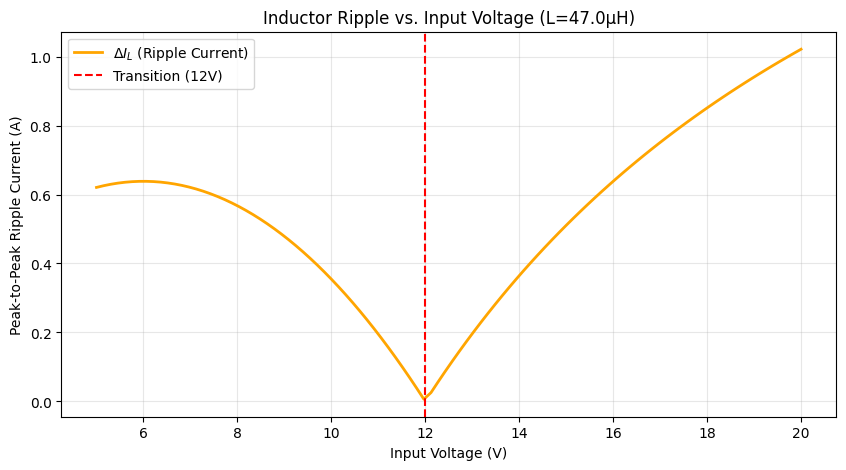

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import constants as cfg

# Generate a range of USB-C input voltages
v_in_range = np.linspace(cfg.USB.V_MIN, cfg.USB.V_MAX, 100)
v_out = cfg.FAN.V_NOMINAL
L = cfg.DESIGN.INDUCTOR.L
f_sw = cfg.DESIGN.F_SW_HZ

def calculate_ripple(vin, vout, l_val, freq):
    if vin > vout: # Buck
        return (vout * (vin - vout)) / (l_val * freq * vin)
    else: # Boost
        duty_cycle = 1 - (vin / vout)
        return (vin * duty_cycle) / (l_val * freq)

ripples = [calculate_ripple(v, v_out, L, f_sw) for v in v_in_range]

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(v_in_range, ripples, label='$\Delta I_L$ (Ripple Current)', color='orange', lw=2)
plt.axvline(x=v_out, color='red', linestyle='--', label='Transition (12V)')

# Formatting
plt.title(f"Inductor Ripple vs. Input Voltage (L={L*1e6:.1f}µH)")
plt.xlabel("Input Voltage (V)")
plt.ylabel("Peak-to-Peak Ripple Current (A)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

LM5176

In [9]:
# Gate Driver
v_gate_drive = 7.35
i_gate_drive_source = 1.8
i_gate_drive_sink = 2.2  
r_h_driver_source_pullup = 1.8
r_h_driver_source_pulldown = 1.1
r_l_driver_source_pullup = 1.7
r_l_driver_source_pulldown = 1.3
t_DT1 = 45e-9
r_gate_ext = 0.0      # External resistor
i_Q_nom = 2e-3 #V_in operating current, VEN/UVLO = 2 V, VFB = 0.9 V
i_Q_max =  4e-3

Inductors

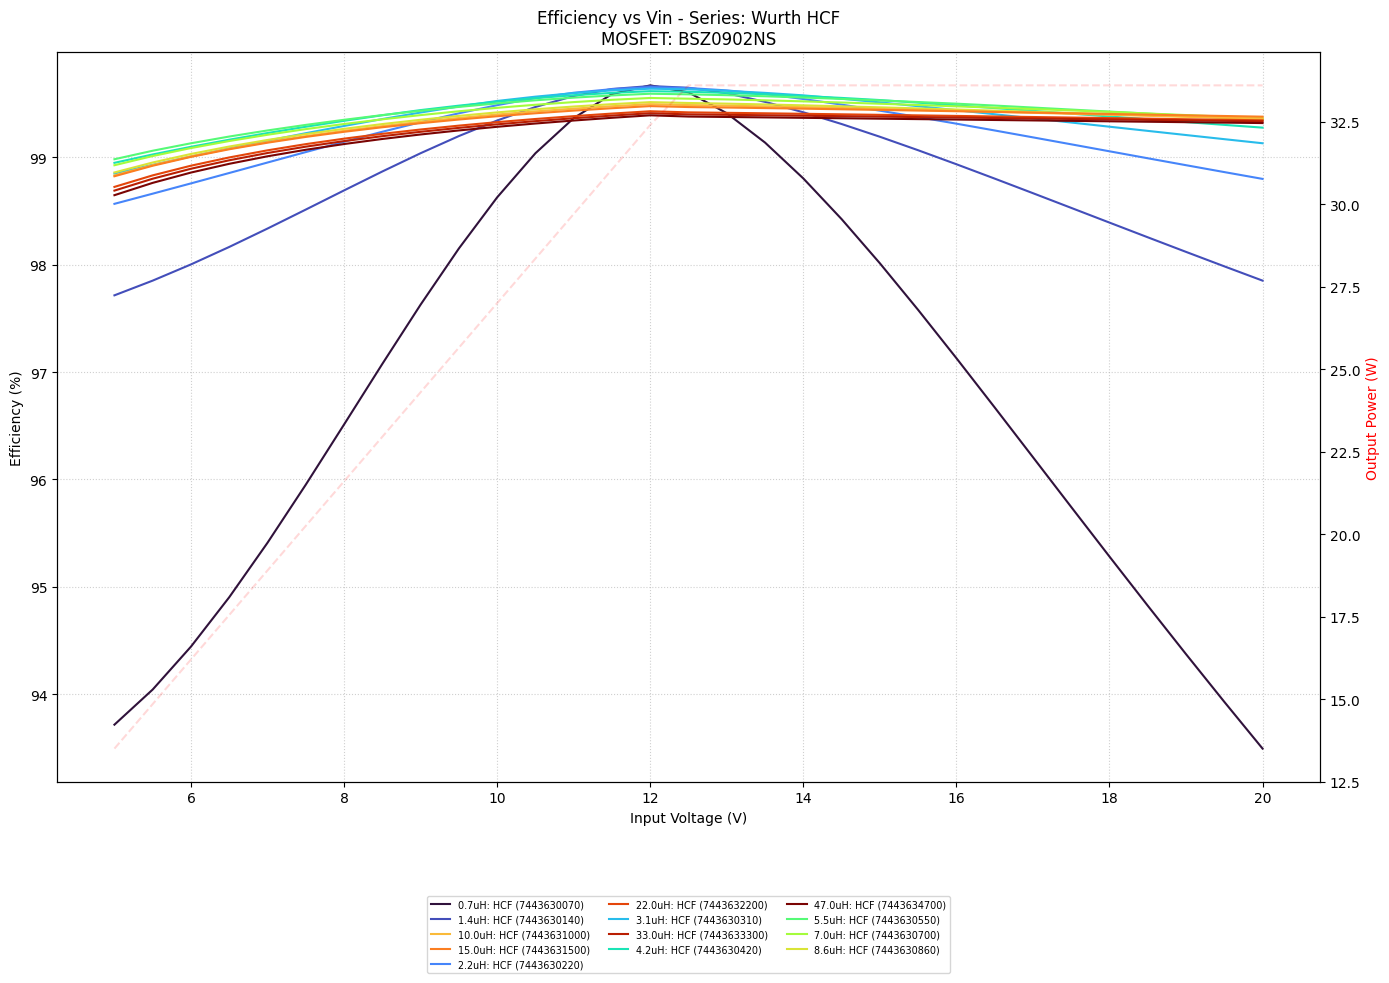

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
ind_df = pd.read_csv('inductors.csv')
mos_df = pd.read_csv('mosfets.csv')

# --- ADVANCED FILTER CONFIGURATION ---
# We use bitwise OR (|) to combine different selection criteria
# 1. Any series containing 'ERU 24'
# 2. Any series 'HCF' specifically in size '2815'

mask = (
    #(ind_df['Series'].str.contains('ERU 24', case=False, na=False)) #| 
    ((ind_df['Series'] == 'HCF') & (ind_df['Size_Code'].astype(str) == '2013'))
)

ind_df = ind_df[mask]

if ind_df.empty:
    print("No parts found matching the criteria! Check CSV naming.")
# -------------------------------------

# Use best MOSFET
best_mos_name = 'BSZ0902NS'
best_mos = mos_df[mos_df['Part Number'] == best_mos_name].iloc[0]

def calc_efficiency_forced_ccm(v_in, v_out, p_out, L, dcr, rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q):
    if p_out <= 0: p_out = 1e-6
    i_out = p_out / v_out
    
    # Logic for Buck vs Boost
    if v_in > v_out: # Buck
        d = v_out / v_in
        i_l_avg = i_out
        delta_il = (v_in - v_out) * d / (L * f_sw)
        v_sw_node = v_in
    else: # Boost
        d = 1 - (v_in / v_out)
        i_l_avg = i_out / (1 - d)
        delta_il = (v_in * d) / (L * f_sw)
        v_sw_node = v_out
    
    i_l_rms = np.sqrt(i_l_avg**2 + (delta_il**2 / 12))
    i_sw_peak = i_l_avg + (delta_il / 2)
    i_sw_valley = i_l_avg - (delta_il / 2)
    
    p_dcr = i_l_rms**2 * dcr
    p_cond = i_l_rms**2 * (rdson * 2)
    t_rise, t_fall = qgd / i_gate_src, qgd / i_gate_snk
    p_sw = 0.5 * v_sw_node * f_sw * (abs(i_sw_peak) * t_fall + abs(i_sw_valley) * t_rise)
    p_gate = 2 * qg * v_gate * f_sw
    p_ic = v_in * i_q
    
    total_loss = p_dcr + p_cond + p_sw + p_gate + p_ic
    return (p_out / (p_out + total_loss)) * 100

# Params
v_in_points = np.linspace(5, 20, 31)
v_out, f_sw, v_gate, i_gate_src, i_gate_snk, i_q = 12, 100e3, 7.35, 1.8, 2.2, 2e-3
max_load_watts, i_in_limit, est_eff = 33.6, 3.0, 0.9
actual_p_out = [min(max_load_watts, v * i_in_limit * est_eff) for v in v_in_points]

rdson = (best_mos['RDSon_10V_Typ(mOhm)'] if not pd.isna(best_mos['RDSon_10V_Typ(mOhm)']) else best_mos['RDSon_4.5V_Typ(mOhm)'])*1e-3
qg = (best_mos['Qg_10V_Typ(nC)'] if not pd.isna(best_mos['Qg_10V_Typ(nC)']) else best_mos['Qg_4.5V_Typ(nC)'])*1e-9
qgd = best_mos['Qgd_Typ(nC)']*1e-9

# Plotting setup
unique_l = sorted(ind_df['Inductance_uH'].unique())
colors = plt.cm.turbo(np.linspace(0, 1, len(unique_l))) # Using turbo for better contrast
l_color_map = dict(zip(unique_l, colors))
line_styles = ['-', '--', ':', '-.', (0, (3, 1, 1, 1))]

fig, ax1 = plt.subplots(figsize=(14, 10))
ax2 = ax1.twinx()

for l_val in unique_l:
    subset = ind_df[ind_df['Inductance_uH'] == l_val]
    color = l_color_map[l_val]
    for idx, (_, ind) in enumerate(subset.iterrows()):
        ls = line_styles[idx % len(line_styles)]
        eff_list = [calc_efficiency_forced_ccm(v, v_out, p, ind['Inductance_uH']*1e-6, ind['DCR_max_mOhm']*1e-3, 
                                               rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q) 
                    for v, p in zip(v_in_points, actual_p_out)]
        
        # Label includes Series and Size for clarity when filtered
        label_text = f"{l_val}uH: {ind['Series']} ({ind['Part_Number']})"
        ax1.plot(v_in_points, eff_list, color=color, linestyle=ls, label=label_text)

ax1.set_xlabel('Input Voltage (V)')
ax1.set_ylabel('Efficiency (%)')
ax2.set_ylabel('Output Power (W)', color='red')
ax2.plot(v_in_points, actual_p_out, color='red', alpha=0.15, linestyle='--', label='Power Envelope')

# Legend and Title
handles, labels = ax1.get_legend_handles_labels()
sorted_indices = np.argsort(labels)
ax1.legend([handles[i] for i in sorted_indices], [labels[i] for i in sorted_indices], 
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize='x-small')

# Dynamically update title based on filters
filter_desc = f"Series: {'Wurth HCF'}"
ax1.set_title(f"Efficiency vs Vin - {filter_desc}\nMOSFET: {best_mos_name}")
ax1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

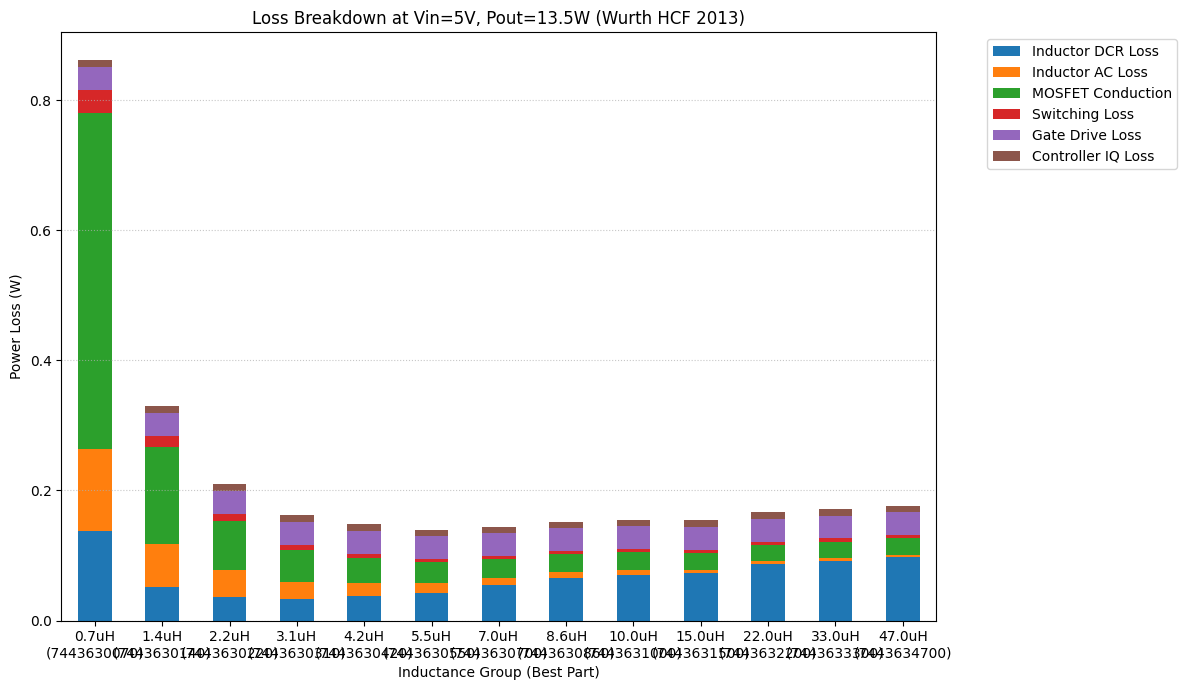

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
ind_df = pd.read_csv('inductors.csv')
mos_df = pd.read_csv('mosfets.csv')

# --- FILTER FOR CERTAIN SERIES OR SIZE ONLY ---
#ind_df = ind_df[ind_df['Size_Code'] == '2815']
ind_df = ind_df[ind_df['Size_Code'] == '2013']
#ind_df = ind_df[ind_df['Series'] == 'ERU 24']
# Best MOSFET
best_mos_name = 'BSZ0501NSI'#'BSZ0902NS'
mos = mos_df[mos_df['Part Number'] == best_mos_name].iloc[0]

# Params
v_in = 5.0
v_out = 12.0
f_sw = 100e3
v_gate = 7.35
i_gate_src = 1.8
i_gate_snk = 2.2
i_q = 2e-3
i_in_limit = 3.0
est_eff = 0.9
p_out = v_in * i_in_limit * est_eff

rdson = (mos['RDSon_10V_Typ(mOhm)'] if not pd.isna(mos['RDSon_10V_Typ(mOhm)']) else mos['RDSon_4.5V_Typ(mOhm)'])*1e-3
qg = (mos['Qg_10V_Typ(nC)'] if not pd.isna(mos['Qg_10V_Typ(nC)']) else mos['Qg_4.5V_Typ(nC)'])*1e-9
qgd = mos['Qgd_Typ(nC)']*1e-9

def get_loss_breakdown(v_in, v_out, p_out, L, dcr, rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, rp=None):
    i_out = p_out / v_out
    # Boost mode since 5V -> 12V
    d = 1 - (v_in / v_out)
    i_l_avg = i_out / (1 - d)
    delta_il = (v_in * d) / (L * f_sw)
    v_sw_node = v_out
    
    i_l_rms = np.sqrt(i_l_avg**2 + (delta_il**2 / 12))
    i_sw_peak = i_l_avg + (delta_il / 2)
    i_sw_valley = i_l_avg - (delta_il / 2)
    
    # Inductor DC Loss
    p_dcr = i_l_rms**2 * dcr
    
    # Inductor AC/Core Loss (using parallel resistor Rp from SPICE model)
    # P_ac = (V_L_rms^2) / Rp
    if rp and not pd.isna(rp) and rp > 0:
        p_ac = ( (v_in**2 * d) + ((v_in - v_out)**2 * (1-d)) ) / rp
    else:
        p_ac = 0.0
        
    p_cond = i_l_rms**2 * (rdson * 2)
    t_rise, t_fall = qgd / i_gate_src, qgd / i_gate_snk
    p_sw = 0.5 * v_sw_node * f_sw * (abs(i_sw_peak) * t_fall + abs(i_sw_valley) * t_rise)
    p_gate = 2 * qg * v_gate * f_sw
    p_ic = v_in * i_q
    
    return {
        'Inductor DCR Loss': p_dcr,
        'Inductor AC Loss': p_ac,
        'MOSFET Conduction': p_cond,
        'Switching Loss': p_sw,
        'Gate Drive Loss': p_gate,
        'Controller IQ Loss': p_ic
    }

# Find best inductor for each value at 5V (lowest DCR)
unique_l = sorted(ind_df['Inductance_uH'].unique())
breakdowns = []
labels = []

for l_val in unique_l:
    subset = ind_df[ind_df['Inductance_uH'] == l_val]
    best_ind = subset.loc[subset['DCR_max_mOhm'].idxmin()]
    
    # Pass Rp_Ohm from the dataframe
    res = get_loss_breakdown(v_in, v_out, p_out, best_ind['Inductance_uH']*1e-6, best_ind['DCR_max_mOhm']*1e-3, 
                            rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, rp=best_ind.get('Rp_Ohm'))
    breakdowns.append(res)
    labels.append(f"{l_val}uH\n({best_ind['Part_Number']})")

df_breakdown = pd.DataFrame(breakdowns, index=labels)

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
df_breakdown.plot(kind='bar', stacked=True, ax=ax)

ax.set_title(f"Loss Breakdown at Vin=5V, Pout={p_out:.1f}W (Wurth HCF 2013)")
ax.set_ylabel("Power Loss (W)")
ax.set_xlabel("Inductance Group (Best Part)")
ax.grid(axis='y', linestyle=':', alpha=0.7)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('loss_breakdown_with_ac.png')

<>:93: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:93: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\harri\AppData\Local\Temp\ipykernel_45864\1072438664.py:93: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("Inductance ($\mu$H)")


                                   Group_Label      Part_Number  \
77  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-333KL   
76  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-223KL   
75  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-153KL   
74  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-103KL   
67                 TDK ERU 24 (25xx Footprint)  B82559A9103A024   
68                 TDK ERU 24 (25xx Footprint)  B82559A0153A024   
69                 TDK ERU 24 (25xx Footprint)  B82559A0203A024   
73  Coilcraft AGP2923 (2723) missing ac losses    AGP2923-682KL   
66                 TDK ERU 24 (25xx Footprint)  B82559A7682A024   
70                 TDK ERU 24 (25xx Footprint)  B82559A0303A024   

    Inductance_uH  Total_Loss_W  
77           33.0      0.106144  
76           22.0      0.106660  
75           15.0      0.107765  
74           10.0      0.110404  
67           10.0      0.110928  
68           15.0      0.111416  
69           20.0      0

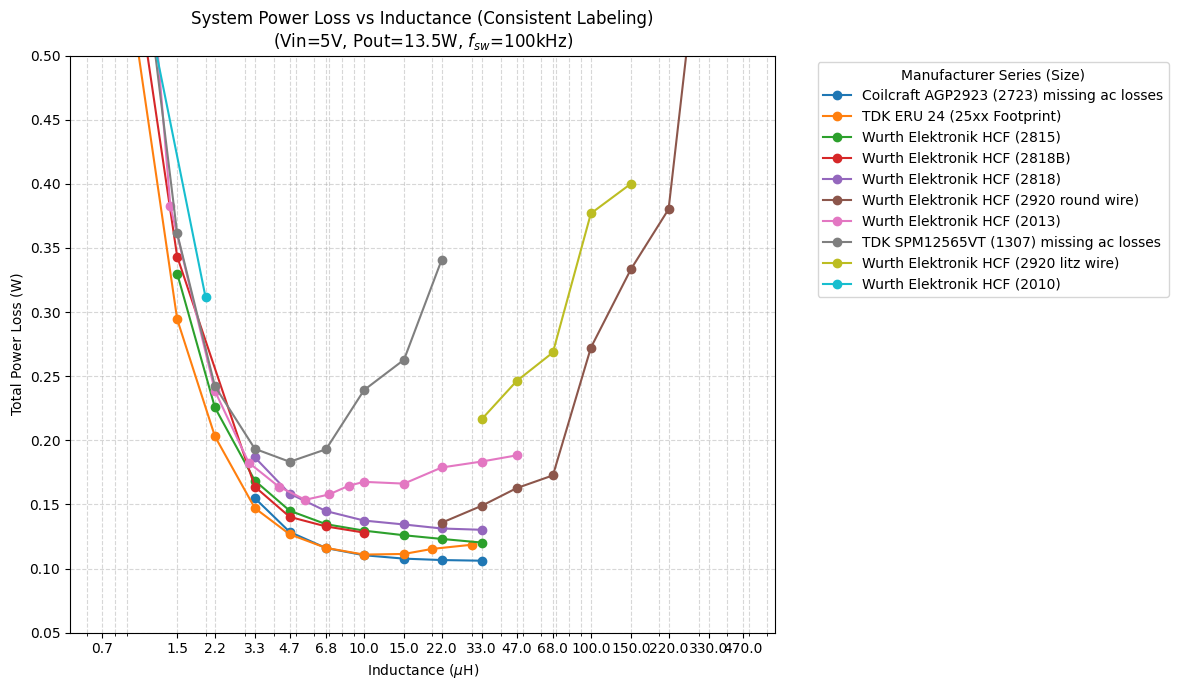

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
ind_df = pd.read_csv('inductors.csv')
mos_df = pd.read_csv('mosfets.csv')

# Handle missing size codes and clean data
ind_df['Size_Code'] = ind_df['Size_Code'].fillna('Unknown')

# Define a "Plotting Group" label - CONSISTENT VERSION
def create_group_label(row):
    if row['Manufacturer'] == 'TDK' and row['Series'] == 'ERU 24':
        # Keeping the footprint grouping as agreed, but making the label style consistent
        return "TDK ERU 24 (25xx Footprint)"
    if row['Manufacturer'] == 'Coilcraft' and row['Series'] == 'AGP2923':
        # Keeping the footprint grouping as agreed, but making the label style consistent
        return f"{row['Manufacturer']} {row['Series']} ({row['Size_Code']}) missing ac losses"
    if row['Manufacturer'] == 'TDK' and row['Series'] == 'SPM12565VT':
        # Keeping the footprint grouping as agreed, but making the label style consistent
        return f"{row['Manufacturer']} {row['Series']} ({row['Size_Code']}) missing ac losses"
    return f"{row['Manufacturer']} {row['Series']} ({row['Size_Code']})"

ind_df['Group_Label'] = ind_df.apply(create_group_label, axis=1)

# Best MOSFET (BSZ0902NS)
best_mos_name = 'BSZ0902NS'
mos = mos_df[mos_df['Part Number'] == best_mos_name].iloc[0]

# Operating Parameters (Same as before)
v_in, v_out = 5.0, 12.0
f_sw = 100e3
v_gate = 7.35
i_gate_src, i_gate_snk = 1.8, 2.2
i_q = 2e-3
i_in_limit = 3.0
est_eff = 0.9
p_out = v_in * i_in_limit * est_eff

rdson = (mos['RDSon_10V_Typ(mOhm)'] if not pd.isna(mos['RDSon_10V_Typ(mOhm)']) else mos['RDSon_4.5V_Typ(mOhm)'])*1e-3
qg = (mos['Qg_10V_Typ(nC)'] if not pd.isna(mos['Qg_10V_Typ(nC)']) else mos['Qg_4.5V_Typ(nC)'])*1e-9
qgd = mos['Qgd_Typ(nC)']*1e-9

def get_total_loss(v_in, v_out, p_out, L, dcr, rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, rp=None):
    i_out = p_out / v_out
    d = 1 - (v_in / v_out)
    i_l_avg = i_out / (1 - d)
    delta_il = (v_in * d) / (L * f_sw)
    v_sw_node = v_out
    
    i_l_rms = np.sqrt(i_l_avg**2 + (delta_il**2 / 12))
    i_sw_peak = i_l_avg + (delta_il / 2)
    i_sw_valley = i_l_avg - (delta_il / 2)
    
    # Inductor AC/Core Loss (using parallel resistor Rp from SPICE model)
    # P_ac = (V_L_rms^2) / Rp
    if rp and not pd.isna(rp) and rp > 0:
        p_ac = ( (v_in**2 * d) + ((v_in - v_out)**2 * (1-d)) ) / rp
    else:
        p_ac = 0.0

    p_dcr = i_l_rms**2 * dcr
    p_cond = i_l_rms**2 * (rdson * 2)
    t_rise, t_fall = qgd / i_gate_src, qgd / i_gate_snk
    p_sw = 0.5 * v_sw_node * f_sw * (abs(i_sw_peak) * t_fall + abs(i_sw_valley) * t_rise)
    p_gate = 2 * qg * v_gate * f_sw
    p_ic = v_in * i_q
    
    return p_dcr + p_ac + p_cond + p_sw + p_gate + p_ic

# Calculate losses
ind_df['Total_Loss_W'] = ind_df.apply(lambda row: get_total_loss(
    v_in, v_out, p_out, row['Inductance_uH']*1e-6, row['DCR_max_mOhm']*1e-3,
    rdson, qgd, qg, f_sw, v_gate, i_gate_src, i_gate_snk, i_q, row['Rp_Ohm']
), axis=1)

# Group and find best within each Inductance value per Family
plot_df = ind_df.loc[ind_df.groupby(['Group_Label', 'Inductance_uH'])['Total_Loss_W'].idxmin()]
plot_df = plot_df.sort_values(['Group_Label', 'Inductance_uH'])

# Plotting
plt.figure(figsize=(12, 7))

# Sort labels by minimum loss
ordered_labels = plot_df.groupby('Group_Label')['Total_Loss_W'].min().sort_values().index

for label in ordered_labels:
    subset = plot_df[plot_df['Group_Label'] == label]
    plt.plot(subset['Inductance_uH'], subset['Total_Loss_W'], marker='o', label=label)

plt.title(f"System Power Loss vs Inductance (Consistent Labeling)\n(Vin=5V, Pout={p_out:.1f}W, $f_{{sw}}$={f_sw/1e3:.0f}kHz)")
plt.xlabel("Inductance ($\mu$H)")
plt.ylabel("Total Power Loss (W)")
plt.xscale('log')
plt.ylim([0.05,0.5])
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(title="Manufacturer Series (Size)", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ticks
unique_l = sorted(plot_df['Inductance_uH'].unique())
min_losses = plot_df.groupby('Inductance_uH')['Total_Loss_W'].min()
clusters = []
if unique_l:
    current_cluster = [unique_l[0]]
    for val in unique_l[1:]:
        if (val - current_cluster[-1]) / current_cluster[-1] < 0.20:
            current_cluster.append(val)
        else:
            clusters.append(current_cluster)
            current_cluster = [val]
    clusters.append(current_cluster)
filtered_ticks = [min(c, key=lambda x: min_losses[x]) for c in clusters]
plt.xticks(filtered_ticks, [str(t) for t in filtered_ticks])

plt.tight_layout()
plt.savefig('loss_by_family_consistent.png')

# Summary
summary = plot_df.sort_values('Total_Loss_W').head(10)[['Group_Label', 'Part_Number', 'Inductance_uH', 'Total_Loss_W']]
print(summary)

Wurth Calculator Values

# Final Conclusions

In [ ]:
r_t = (1 / f_sw-190e-9) / 116e-12 # LM5176 datasheet
inductor_choice = "47 uH, Wurth 7443634700"